# Roessler — Single-Scroll Chaotic Oscillator

## Overview

The Rössler system (1976) is a minimal three-variable ODE with a single-scroll strange attractor:

### Equations

$$\frac{dx}{dt} = -y - z$$
$$\frac{dy}{dt} = x + a\,y$$
$$\frac{dz}{dt} = b + z(x - c)$$

Compared to Lorenz63, the attractor is simpler: one scroll rather than two. The variable `z`
spikes periodically while `x` and `y` circulate quasi-periodically in the plane below.
Chaos arises from the nonlinear $z(x-c)$ term — when $x > c$ the $z$ variable grows exponentially
before being reset.

### Parameters

| Name | Description | Default (canonical chaos) |
|------|-------------|---------------------------|
| `a` | y-feedback strength | 0.2 |
| `b` | z-equation offset | 0.2 |
| `c` | Nonlinear threshold | 5.7 |

`c` controls the bifurcation structure: small `c` → periodic orbits; large `c` → chaos.
State variables: `x`, `y`, `z`. No diagnostic variables.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from paleobeasts.signal_models.roessler import Roessler

## Canonical attractor

In [2]:
# a=0.2, b=0.2, c=5.7 — canonical chaotic parameter set
model = Roessler()
output = model.integrate(t_span=(0, 300), y0=[0.1, 0.0, 0.0], method='RK45')

x = output.state_variables['x']
y = output.state_variables['y']
z = output.state_variables['z']
t = output.time

print(f'Steps: {len(t)}')
print(f'x range: [{np.min(x):.2f}, {np.max(x):.2f}]')
print(f'z range: [{np.min(z):.2f}, {np.max(z):.2f}]')

Steps: 8029
x range: [-9.08, 11.41]
z range: [0.00, 22.60]


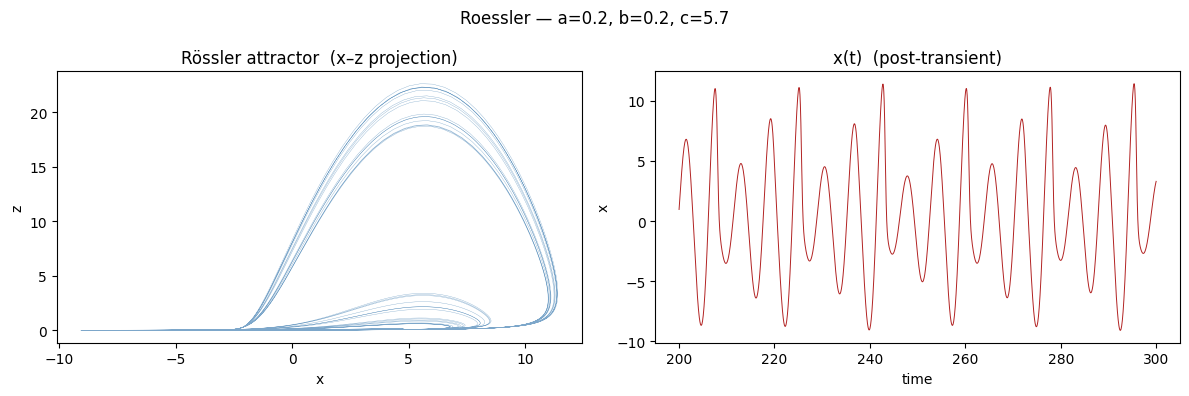

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# x-z projection — the characteristic single scroll
axes[0].plot(x, z, lw=0.25, color='steelblue', alpha=0.7)
axes[0].set_xlabel('x'); axes[0].set_ylabel('z')
axes[0].set_title('Rössler attractor  (x–z projection)')

# x(t) time series — quasi-periodic spirals with irregular z-spikes
t_arr = np.asarray(t)
mask = (t_arr >= 200)
axes[1].plot(t_arr[mask], x[mask], lw=0.7, color='firebrick')
axes[1].set_xlabel('time'); axes[1].set_ylabel('x')
axes[1].set_title('x(t)  (post-transient)')

fig.suptitle('Roessler — a=0.2, b=0.2, c=5.7')
plt.tight_layout(); plt.show()

**Figure.** Left: x–z projection of the single-scroll attractor. Unlike the Lorenz butterfly, there is only one scroll — trajectories spiral outward in the xy-plane until a nonlinear spike in $z$ resets them to a tighter orbit. The band structure reflects quasi-regular winding with slowly varying amplitude. Right: $x(t)$ shows largely regular oscillations punctuated by occasional amplitude irregularities — Rössler is chaotic but less violently so than Lorenz at these parameters.

### x, y, z time series

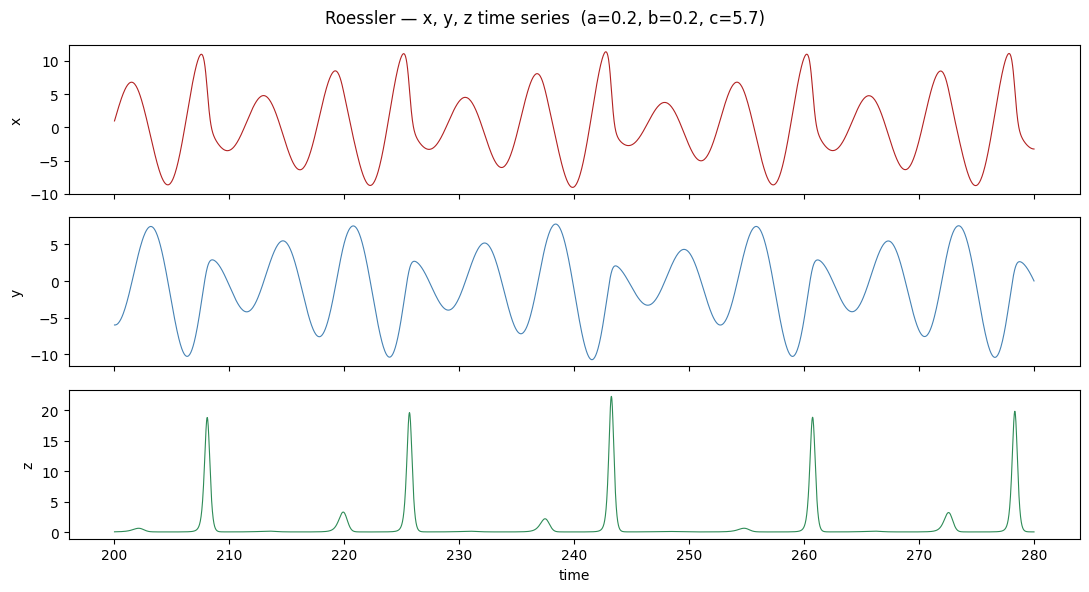

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
mask_ts = (t_arr >= 200) & (t_arr <= 280)

for ax, var, color, label in zip(axes,
                                  [x, y, z],
                                  ['firebrick', 'steelblue', 'seagreen'],
                                  ['x', 'y', 'z']):
    ax.plot(t_arr[mask_ts], var[mask_ts], lw=0.8, color=color)
    ax.set_ylabel(label)

axes[-1].set_xlabel('time')
fig.suptitle('Roessler — x, y, z time series  (a=0.2, b=0.2, c=5.7)')
plt.tight_layout(); plt.show()

**Figure.** $x$ and $y$ oscillate in approximate anti-phase at the slow frequency. $z$ is near zero for most of the cycle, then spikes sharply upward when the $(x, y)$ trajectory reaches the outer edge of the spiral. Each $z$-spike slightly perturbs the next orbit — this sensitive amplification of small differences is the source of chaos.

## Effect of `c` — periodic to chaotic transition

`c` controls the dominant dynamics. Below `c ≈ 4.2` the attractor is periodic;
above that period-doubling cascades to chaos by `c ≈ 5.7`.

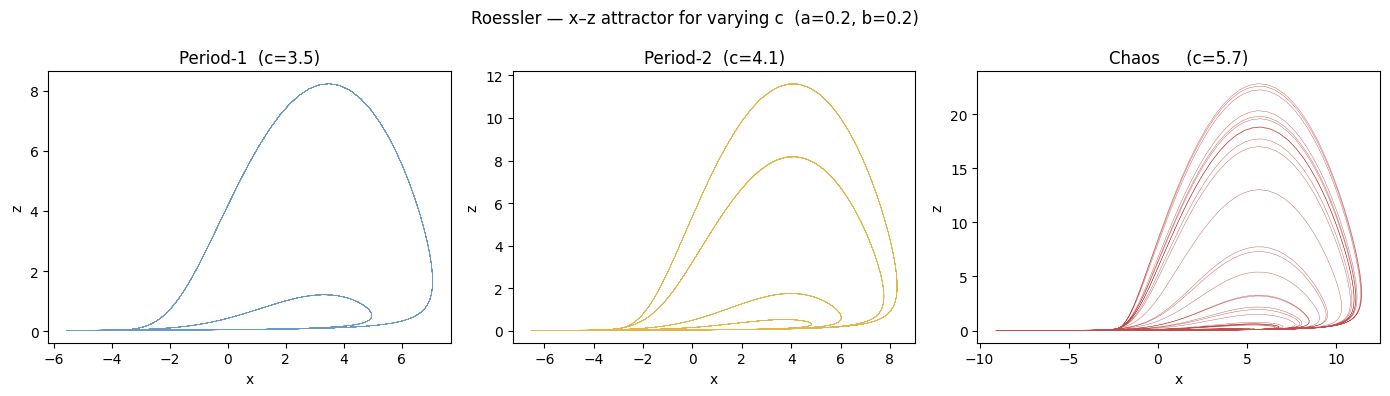

In [5]:
c_cases = [
    (3.5, 'Period-1  (c=3.5)',  'steelblue'),
    (4.1, 'Period-2  (c=4.1)',  'goldenrod'),
    (5.7, 'Chaos     (c=5.7)',  'firebrick'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (c_val, label, color) in zip(axes, c_cases):
    m = Roessler(c=c_val)
    out = m.integrate(t_span=(0, 400), y0=[0.1, 0.0, 0.0], method='RK45')
    xv = out.state_variables['x']
    zv = out.state_variables['z']
    tv = np.asarray(out.time)
    mk = tv > 200
    ax.plot(xv[mk], zv[mk], lw=0.3, color=color, alpha=0.8)
    ax.set_xlabel('x'); ax.set_ylabel('z')
    ax.set_title(label)

fig.suptitle('Roessler — x–z attractor for varying c  (a=0.2, b=0.2)')
plt.tight_layout(); plt.show()

**Figure.** x–z attractor for three values of $c$. Period-1 ($c=3.5$): a single closed orbit — the trajectory retraces the same path every cycle. Period-2 ($c=4.1$): the orbit has split into two nested loops; every other revolution is slightly larger, doubling the period. Chaos ($c=5.7$): no two loops are the same; the band has thickened into a continuous sheet characteristic of a strange attractor.

## Solver notes

`RK45` is appropriate. The Rössler system is not stiff at canonical parameters.

**`t_span` must start at 0 or later.** Like `Lorenz63`, this model accumulates state in
`dydt` using a `if t > 0` guard. Negative start times leave a gap in the output.

**Discard a transient** (first ~100 time units) before taking attractor statistics — the
trajectory may start far from the attractor depending on the initial condition.